# Feature Importance Analysis

Uses permutation importance, SHAP, and progressive ablation to identify which eBPF features carry signal and which drive the generalisation drop seen in notebook 01.

**RQ2:** Which eBPF features contribute most to improved detection?

In [ ]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *
from ml.notebooks.modeling_pipeline import (
    load_model_pack,
    prepare_split,
    align_to_features,
    binary_metrics,
)

PERMUTATION_SAMPLE_N = 3000
PERMUTATION_REPEATS = 3
SHAP_SAMPLE_N = 1000
SHAP_BACKGROUND_N = 64
ABLATION_SAMPLE_N = 3000

FI_DIR = REPORTS_DIR / 'feature_importance' / f'seed{RANDOM_SEED}'
FI_DIR.mkdir(parents=True, exist_ok=True)
print('[*] Output:', FI_DIR)


BASELINE_COLOR = "#4C78A8"
EBPF_COLOR = "#F58518"
NEUTRAL_COLOR = "#9AA1A9"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#6B7280',
    'axes.labelcolor': '#111827',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'grid.color': '#D7DBDF',
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'legend.frameon': False,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

def savefig(fig, path, dpi=180):
    """Save matplotlib figure to path."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')


[*] Output: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104


## Load Saved Main-Experiment Artifacts

Loads the trained HistGradientBoosting model packs and the realistic-test samples used for importance and SHAP.

In [2]:
PACKS = {
    'baseline': load_model_pack('baseline', artifact='headline', seed=RANDOM_SEED),
    'ebpf': load_model_pack('ebpf', artifact='headline', seed=RANDOM_SEED),
}

SPLIT4 = {'baseline': SPLITS_4_BASELINE, 'ebpf': SPLITS_4_EBPF}

PERMUTATION_SAMPLE_N = 5000
PERMUTATION_REPEATS = 5
SHAP_SAMPLE_N = 384
SHAP_BACKGROUND_N = 64

def stratified_sample(df: pd.DataFrame, sample_n: int, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Stratified-sample up to sample_n rows from df preserving attack/benign ratio."""
    if len(df) <= sample_n:
        return df.copy()
    rng = np.random.default_rng(seed)
    pos_idx = df.index[df['is_attack'] == 1].to_numpy()
    neg_idx = df.index[df['is_attack'] == 0].to_numpy()
    pos_n = int(round(sample_n * len(pos_idx) / len(df)))
    pos_n = min(max(pos_n, 1), len(pos_idx))
    neg_n = min(sample_n - pos_n, len(neg_idx))
    if neg_n <= 0:
        neg_n = min(1, len(neg_idx))
    chosen = np.concatenate([
        rng.choice(pos_idx, size=pos_n, replace=False),
        rng.choice(neg_idx, size=neg_n, replace=False),
    ])
    rng.shuffle(chosen)
    return df.loc[chosen].copy()

def prepare_xy(df: pd.DataFrame, feature_list):
    """Drop metadata columns and return (X_numeric, y_binary) arrays from df."""
    prep = prepare_split(df, feature_list=feature_list)
    return align_to_features(prep.X, feature_list), prep.y

DATA = {}
for fs in ['baseline', 'ebpf']:
    feat = PACKS[fs]['features']
    te_real_df = pd.read_parquet(SPLIT4[fs] / 'test_realistic.parquet')
    perm_df = stratified_sample(te_real_df, PERMUTATION_SAMPLE_N, seed=RANDOM_SEED)
    shap_df = stratified_sample(te_real_df, SHAP_SAMPLE_N, seed=RANDOM_SEED + 1)

    Xperm, yperm = prepare_xy(perm_df, feat)
    Xablate, yablate = prepare_xy(te_real_df, feat)
    Xshap, yshap = prepare_xy(shap_df, feat)

    DATA[fs] = {
        'Xperm': Xperm, 'yperm': yperm,
        'Xablate': Xablate, 'yablate': yablate,
        'Xshap': Xshap, 'yshap': yshap,
        'realistic_rows': int(len(te_real_df)),
        'features': feat,
    }
    del te_real_df, perm_df, shap_df
    print(
        f"[*] {fs}: selected={PACKS[fs]['selected_model_name']} "
        f"features={len(feat)} realistic_rows={DATA[fs]['realistic_rows']:,} "
        f"perm_sample={len(DATA[fs]['Xperm']):,} shap_sample={len(DATA[fs]['Xshap']):,} "
        f"ablation_rows={len(DATA[fs]['Xablate']):,}"
    )


[*] baseline: selected=hgb_balanced features=10 realistic_rows=546,207 perm_sample=5,000 shap_sample=384 ablation_rows=546,207
[*] ebpf: selected=hgb_balanced features=17 realistic_rows=546,207 perm_sample=5,000 shap_sample=384 ablation_rows=546,207


## Method 1: Permutation Importance

Measures AUC drop when each feature is randomly permuted over 30 repeats. Negative values mean the feature is hurting the model.

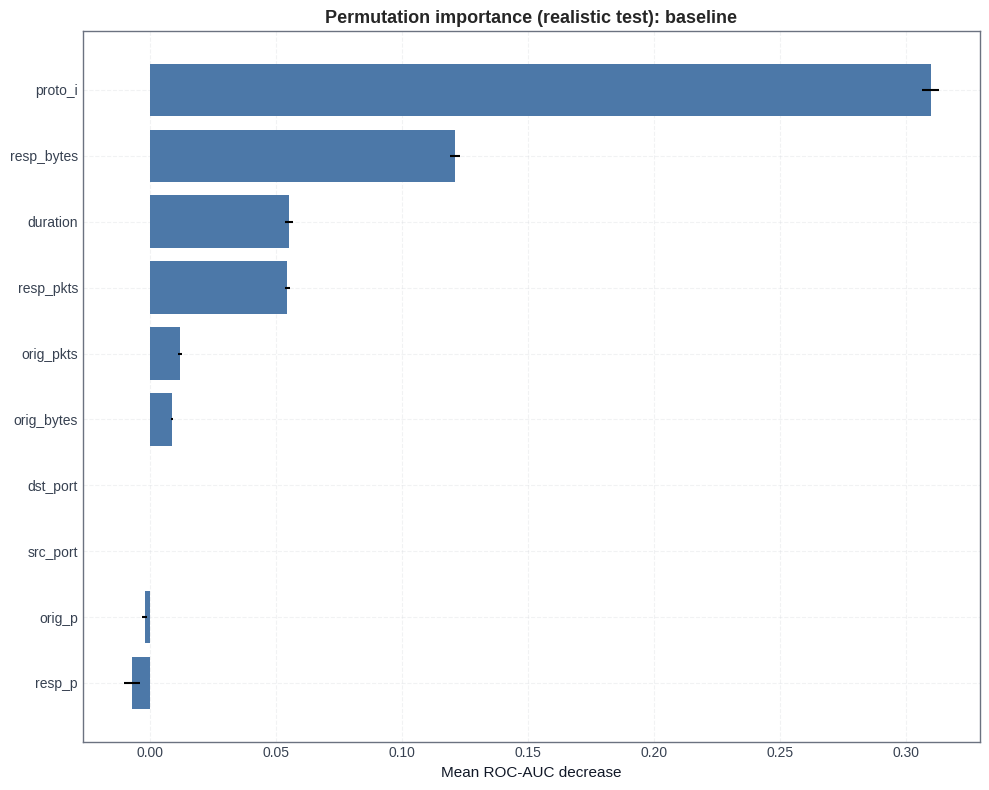

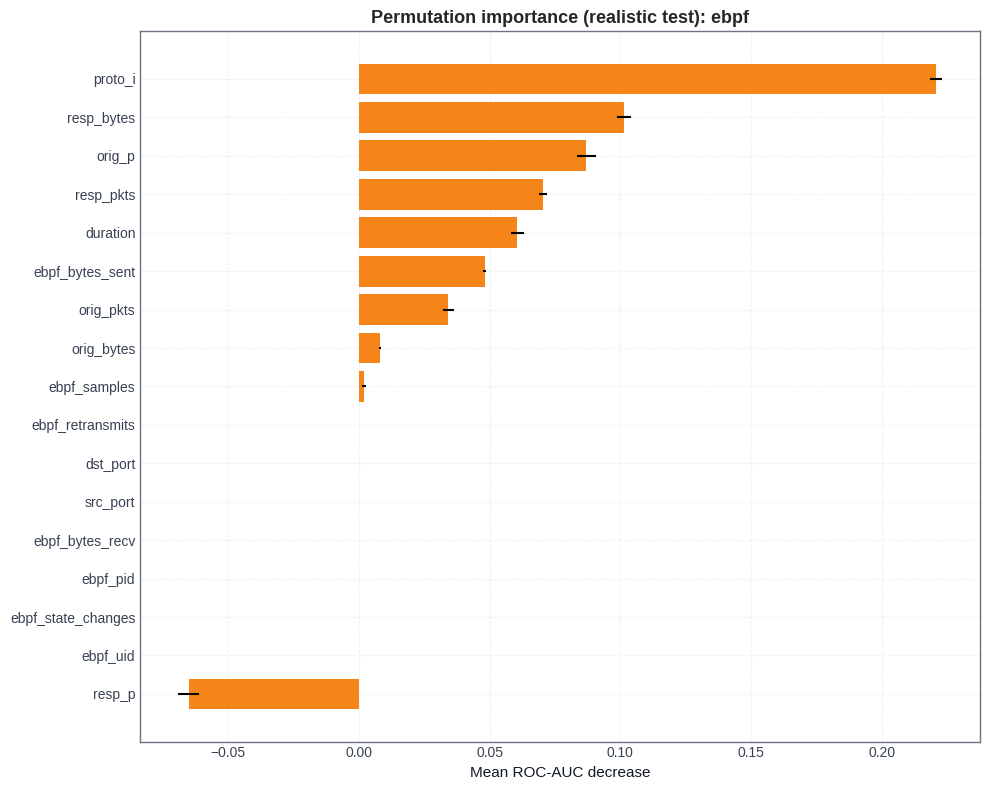

In [3]:
def run_permutation(fs_name: str, sample_n: int = PERMUTATION_SAMPLE_N, n_repeats: int = PERMUTATION_REPEATS):
    """Run permutation feature importance for a named feature set and return a ranked DataFrame."""
    pack = PACKS[fs_name]
    model = pack['model']
    d = DATA[fs_name]

    X = d['Xperm']
    y = d['yperm']

    pi = permutation_importance(
        model,
        X,
        y,
        scoring='roc_auc',
        n_repeats=n_repeats,
        random_state=RANDOM_SEED,
        n_jobs=1,
    )
    imp = pd.DataFrame({
        'feature': d['features'],
        'importance_mean': pi.importances_mean,
        'importance_std': pi.importances_std,
    }).sort_values('importance_mean', ascending=False)
    imp['importance_mean_clip'] = imp['importance_mean'].clip(lower=0)
    total_positive = float(imp['importance_mean_clip'].sum())
    imp['cumulative_importance_share'] = (
        imp['importance_mean_clip'].cumsum() / total_positive if total_positive > 0 else 0.0
    )
    imp['feature_origin'] = np.where(
        imp['feature'].str.contains('ebpf|bpf|pid|ppid|uid|gid|comm|exe|cmd|sock|sk_|tcp_|udp_|netns|inode|tgid', case=False, regex=True),
        'ebpf-derived',
        'zeek/core',
    )

    imp.to_csv(FI_DIR / f'permutation_{fs_name}.csv', index=False)

    top = imp.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], color=EBPF_COLOR if fs_name == 'ebpf' else BASELINE_COLOR)
    ax.set_title(f'Permutation importance (realistic test): {fs_name}')
    ax.set_xlabel('Mean ROC-AUC decrease')
    plt.tight_layout()
    plt.savefig(FI_DIR / f'permutation_{fs_name}.png', dpi=150)
    plt.show()

    return imp

IMP_BASE = run_permutation('baseline')
IMP_EBPF = run_permutation('ebpf')


## Importance Concentration and Source Composition

Shows how much of the total importance sits in the top-ranked features and how the Zeek vs eBPF breakdown looks.

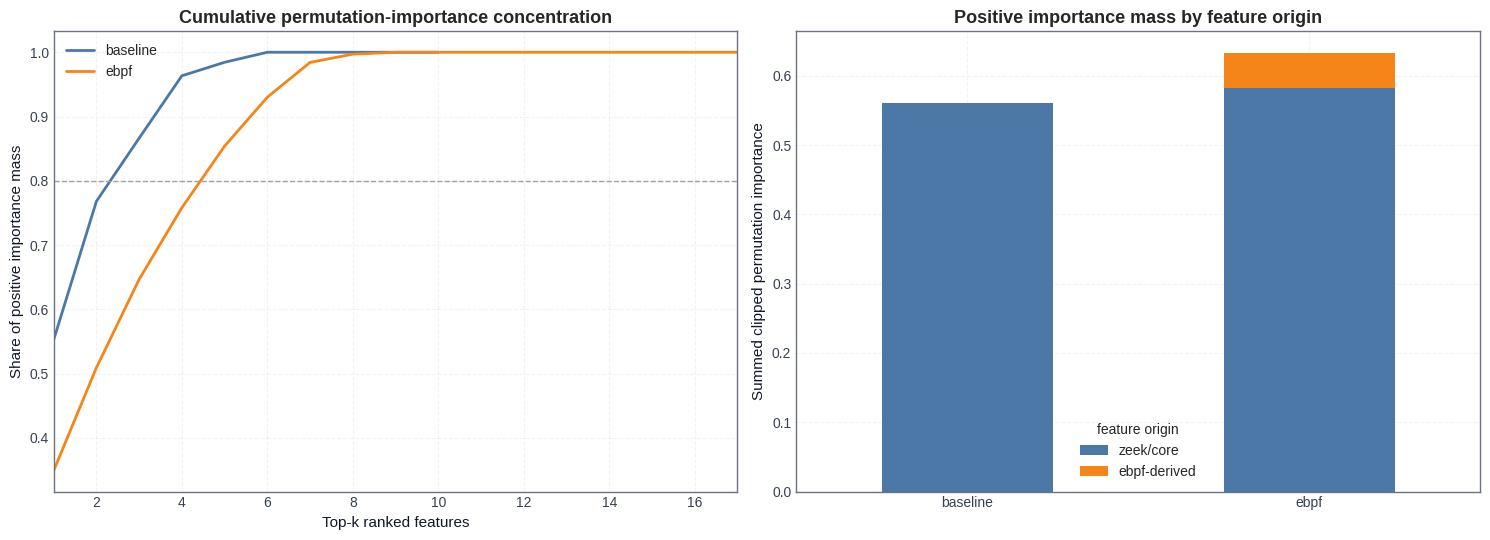

[+] Saved importance concentration plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/importance_concentration_and_origin.png


In [4]:
perm_map = {'baseline': IMP_BASE, 'ebpf': IMP_EBPF}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for fs_name, color in [('baseline', BASELINE_COLOR), ('ebpf', EBPF_COLOR)]:
    imp = perm_map[fs_name].copy()
    x = np.arange(1, len(imp) + 1)
    axes[0].plot(x, imp['cumulative_importance_share'], linewidth=2, color=color, label=fs_name)
axes[0].axhline(0.8, color=NEUTRAL_COLOR, linestyle='--', linewidth=1)
axes[0].set_title('Cumulative permutation-importance concentration')
axes[0].set_xlabel('Top-k ranked features')
axes[0].set_ylabel('Share of positive importance mass')
axes[0].set_xlim(1, max(len(IMP_BASE), len(IMP_EBPF)))
axes[0].legend()

origin_rows = []
for fs_name, imp in perm_map.items():
    origin_rows.append(
        imp.groupby('feature_origin', dropna=False)['importance_mean_clip']
        .sum()
        .rename(fs_name)
    )
origin_df = pd.concat(origin_rows, axis=1).fillna(0).T
origin_df = origin_df.reindex(['baseline', 'ebpf']).fillna(0)
origin_df.plot(kind='bar', stacked=True, ax=axes[1], color=[BASELINE_COLOR, EBPF_COLOR])
axes[1].set_title('Positive importance mass by feature origin')
axes[1].set_ylabel('Summed clipped permutation importance')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='feature origin')

plt.tight_layout()
out = FI_DIR / 'importance_concentration_and_origin.png'
savefig(fig, out)
plt.show()
print(f'[+] Saved importance concentration plot: {out}')


## Method 2: Feature-Group Masking

Replaces all eBPF features with training-set medians at inference time (no retraining) to isolate the group contribution.

              variant        model  n_features  roc_auc_realistic  pr_auc_realistic  f1_realistic  recall_realistic  precision_realistic  delta_roc_auc_realistic_vs_all  delta_pr_auc_realistic_vs_all  delta_f1_realistic_vs_all  delta_recall_realistic_vs_all  delta_precision_realistic_vs_all
         all_features hgb_balanced          17             0.8005            0.7512        0.4989            0.3675               0.7762                          0.0000                         0.0000                     0.0000                         0.0000                            0.0000
zeek_only_masked_view hgb_balanced          10             0.6949            0.6852        0.5014            0.3658               0.7964                         -0.1056                        -0.0660                     0.0025                        -0.0017                            0.0202
ebpf_only_masked_view hgb_balanced           7             0.6317            0.5917        0.0000            0.0000         

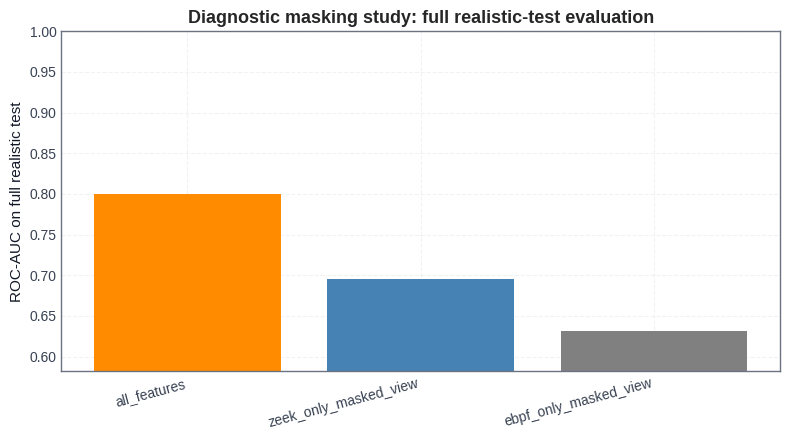

In [5]:
EBPF_HINTS = ('ebpf', 'bpf', 'pid', 'ppid', 'uid', 'gid', 'comm', 'exe', 'cmd', 'sock', 'sk_', 'tcp_', 'udp_', 'netns', 'inode', 'tgid')

fs = 'ebpf'
d = DATA[fs]
pack = PACKS[fs]

feat_all = d['features']
feat_zeek = [f for f in feat_all if not any(h in f.lower() for h in EBPF_HINTS)]
feat_ebpf_only = [f for f in feat_all if any(h in f.lower() for h in EBPF_HINTS)]

X_base = d['Xablate'].copy()
y_base = d['yablate']
score_base = pack['model'].predict_proba(X_base)[:, 1] if hasattr(pack['model'], 'predict_proba') else pack['model'].decision_function(X_base)
if np.ndim(score_base) != 1:
    score_base = score_base[:, 1]
pred_base = (score_base >= pack.get('threshold', 0.5)).astype(int)
base_metrics = binary_metrics(y_base, pred_base, score_base)

median_fill = pd.Series(0.0, index=feat_all)
if hasattr(pack['model'], 'named_steps') and 'impute' in pack['model'].named_steps:
    median_fill = pd.Series(pack['model'].named_steps['impute'].statistics_, index=feat_all)

rows = [{
    'variant': 'all_features',
    'model': pack['selected_model_name'],
    'n_features': len(feat_all),
    'roc_auc_realistic': base_metrics['roc_auc'],
    'pr_auc_realistic': base_metrics['pr_auc'],
    'f1_realistic': base_metrics['f1'],
    'recall_realistic': base_metrics['recall'],
    'precision_realistic': base_metrics['precision'],
}]

for name, feats in [('zeek_only_masked_view', feat_zeek), ('ebpf_only_masked_view', feat_ebpf_only)]:
    if not feats:
        continue
    X_masked = X_base.copy()
    drop_cols = [c for c in feat_all if c not in feats]
    for col in drop_cols:
        X_masked.loc[:, col] = median_fill[col]
    score = pack['model'].predict_proba(X_masked)[:, 1] if hasattr(pack['model'], 'predict_proba') else pack['model'].decision_function(X_masked)
    if np.ndim(score) != 1:
        score = score[:, 1]
    pred = (score >= pack.get('threshold', 0.5)).astype(int)
    metrics = binary_metrics(y_base, pred, score)
    rows.append({
        'variant': name,
        'model': pack['selected_model_name'],
        'n_features': len(feats),
        'roc_auc_realistic': metrics['roc_auc'],
        'pr_auc_realistic': metrics['pr_auc'],
        'f1_realistic': metrics['f1'],
        'recall_realistic': metrics['recall'],
        'precision_realistic': metrics['precision'],
    })

ab_df = pd.DataFrame(rows)
baseline_row = ab_df.loc[ab_df['variant'] == 'all_features'].iloc[0]
for metric in ['roc_auc_realistic', 'pr_auc_realistic', 'f1_realistic', 'recall_realistic', 'precision_realistic']:
    ab_df[f'delta_{metric}_vs_all'] = ab_df[metric] - baseline_row[metric]
print(ab_df.to_string(index=False, float_format='{:.4f}'.format))
ab_df.to_csv(FI_DIR / 'ebpf_ablation_realistic.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = ab_df.set_index('variant').loc[['all_features'] + [v for v in ab_df['variant'] if v != 'all_features']].reset_index()
ax.bar(plot_df['variant'], plot_df['roc_auc_realistic'], color=['darkorange', 'steelblue', 'grey'][:len(plot_df)])
ax.set_ylim(max(0, plot_df['roc_auc_realistic'].min() - 0.05), 1.0)
ax.set_ylabel('ROC-AUC on full realistic test')
ax.set_title('Diagnostic masking study: full realistic-test evaluation')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FI_DIR / 'ebpf_ablation_realistic.png', dpi=150)
plt.show()


## Method 3: SHAP

SHAP values on a 384-row sample of the realistic test set. Provides a second ranking to cross-check against permutation importance.

[*] Computing SHAP values for baseline (384 samples)...
  Top 5 SHAP features (baseline): ['proto_i', 'resp_p', 'resp_bytes', 'resp_pkts', 'orig_p']


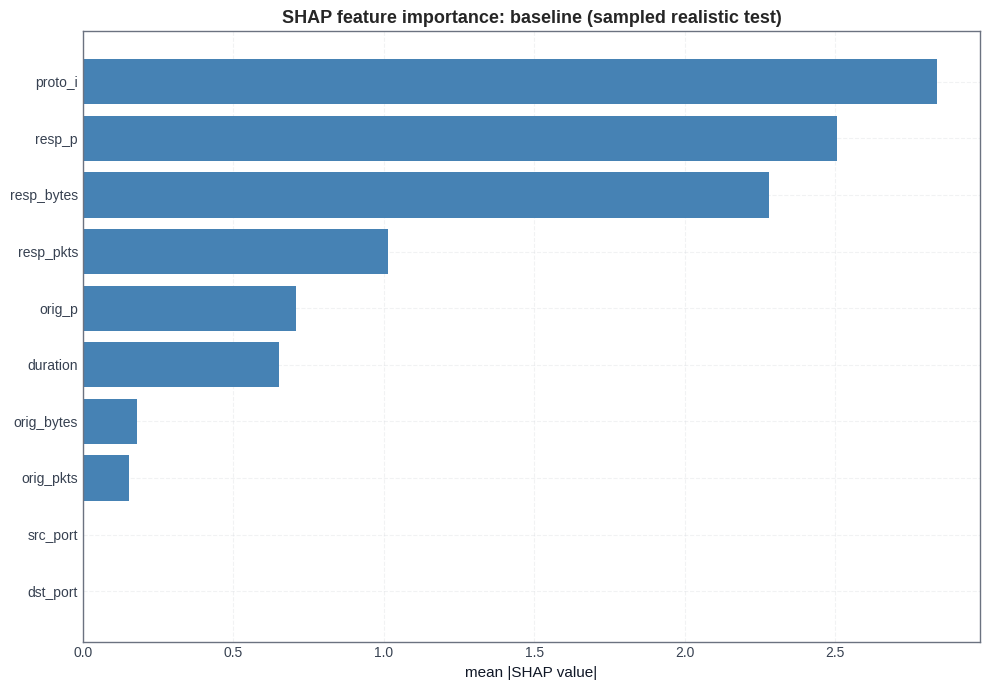

  Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/shap_bar_baseline.png
[*] Computing SHAP values for ebpf (384 samples)...
  Top 5 SHAP features (ebpf): ['resp_bytes', 'resp_p', 'proto_i', 'resp_pkts', 'orig_p']


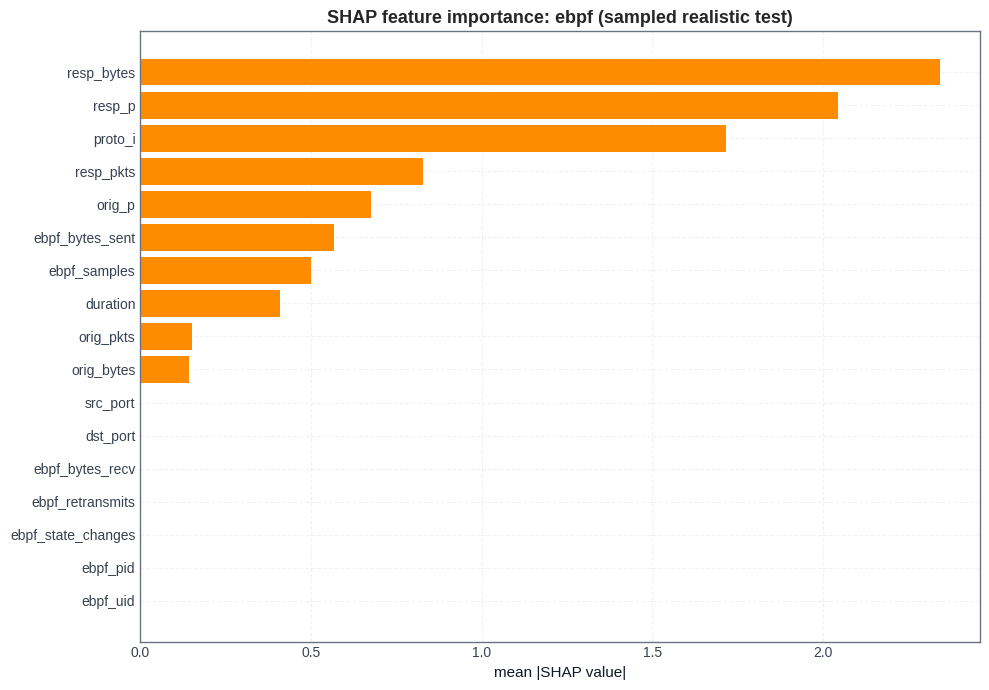

  Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/shap_bar_ebpf.png

[*] eBPF feature consensus ranking
           feature  importance_mean  importance_std  importance_mean_clip  cumulative_importance_share feature_origin  permutation_rank  shap_rank  mean_rank
   ebpf_bytes_sent           0.0481          0.0005                0.0481                       0.9301   ebpf-derived                 1          1     1.0000
      ebpf_samples           0.0019          0.0008                0.0019                       1.0000   ebpf-derived                 2          2     2.0000
  ebpf_retransmits           0.0000          0.0000                0.0000                       1.0000   ebpf-derived                 3          4     3.5000
   ebpf_bytes_recv           0.0000          0.0000                0.0000                       1.0000   ebpf-derived                 4          3     3.5000
          ebpf_pid           0.0000          0.0000  

In [ ]:
import shap

def prepare_shap_inputs(model, X_df: pd.DataFrame):
    """Extract the inner classifier and processed feature matrix for SHAP analysis."""
    if hasattr(model, 'named_steps') and 'clf' in model.named_steps:
        clf = model.named_steps['clf']
        if len(model.steps) > 1:
            X_proc = model[:-1].transform(X_df)
        else:
            X_proc = X_df.to_numpy()
        return clf, np.asarray(X_proc), list(X_df.columns)
    return model, X_df.to_numpy(), list(X_df.columns)

if shap is not None:
    for fs_name in ['baseline', 'ebpf']:
        pack = PACKS[fs_name]
        d = DATA[fs_name]
        X_shap = d['Xshap']
        print(f'[*] Computing SHAP values for {fs_name} ({len(X_shap)} samples)...')

        expl_model, X_proc, feature_names = prepare_shap_inputs(pack['model'], X_shap)
        selected = pack.get('selected_model_name', '')

        if any(tag in selected for tag in ('hgb', 'rf', 'et')) or 'forest' in str(type(expl_model)).lower() or 'gradient' in str(type(expl_model)).lower():
            explainer = shap.TreeExplainer(expl_model)
            shap_values = explainer.shap_values(X_proc)
        elif 'logreg' in selected or 'logistic' in str(type(expl_model)).lower():
            background = X_proc[: min(SHAP_BACKGROUND_N, len(X_proc))]
            explainer = shap.LinearExplainer(expl_model, background)
            shap_values = explainer.shap_values(X_proc)
        else:
            print(f'  [!] Unsupported model for bounded SHAP run: {selected or type(expl_model).__name__}')
            continue

        if isinstance(shap_values, list):
            shap_values = shap_values[-1]

        mean_shap = np.abs(shap_values).mean(axis=0)
        shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap}).sort_values('mean_abs_shap', ascending=False)
        shap_df.head(20).to_csv(FI_DIR / f'shap_top20_{fs_name}.csv', index=False)
        print(f'  Top 5 SHAP features ({fs_name}): {shap_df.head(5).feature.tolist()}')

        top = shap_df.head(20).iloc[::-1]
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(top['feature'], top['mean_abs_shap'], color='darkorange' if fs_name == 'ebpf' else 'steelblue')
        ax.set_title(f'SHAP feature importance: {fs_name} (sampled realistic test)')
        ax.set_xlabel('mean |SHAP value|')
        plt.tight_layout()
        out = FI_DIR / f'shap_bar_{fs_name}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved: {out}')

    if (FI_DIR / 'permutation_ebpf.csv').exists() and (FI_DIR / 'shap_top20_ebpf.csv').exists():
        perm = pd.read_csv(FI_DIR / 'permutation_ebpf.csv')
        perm = perm[perm['feature'].str.startswith('ebpf_')].copy().reset_index(drop=True)
        perm['permutation_rank'] = np.arange(1, len(perm) + 1)
        shap_top = pd.read_csv(FI_DIR / 'shap_top20_ebpf.csv')
        shap_top = shap_top[shap_top['feature'].str.startswith('ebpf_')].copy().reset_index(drop=True)
        shap_top['shap_rank'] = np.arange(1, len(shap_top) + 1)
        consensus = perm.merge(shap_top[['feature', 'shap_rank']], on='feature', how='outer')
        max_rank = max(len(perm), len(shap_top), 1) + 1
        consensus['permutation_rank'] = consensus['permutation_rank'].fillna(max_rank)
        consensus['shap_rank'] = consensus['shap_rank'].fillna(max_rank)
        consensus['mean_rank'] = consensus[['permutation_rank', 'shap_rank']].mean(axis=1)
        consensus = consensus.sort_values('mean_rank').reset_index(drop=True)
        consensus.to_csv(FI_DIR / 'ebpf_feature_consensus.csv', index=False)
        print('\n[*] eBPF feature consensus ranking')
        print(consensus.to_string(index=False, float_format='{:.4f}'.format))

    print('\n[+] SHAP analysis complete.')


## Rank Consensus Between Permutation and SHAP

Compares the two rankings. Both methods agree that `ebpf_bytes_sent` is the only eBPF feature with consistent signal and the rest are noise.

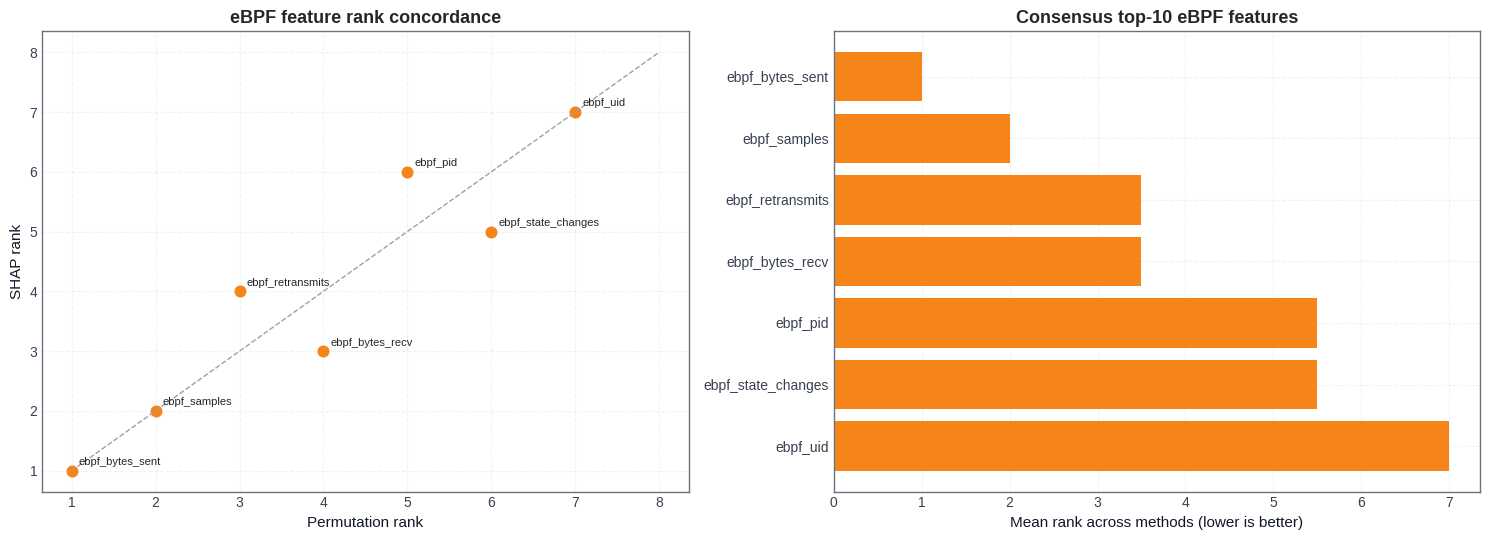

[+] Saved rank-consensus plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/ebpf_rank_consensus.png


In [7]:
consensus_path = FI_DIR / 'ebpf_feature_consensus.csv'
if consensus_path.exists():
    consensus = pd.read_csv(consensus_path).head(20).copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    axes[0].scatter(consensus['permutation_rank'], consensus['shap_rank'], s=90, color=EBPF_COLOR, edgecolor='white', linewidth=0.8)
    lim = max(consensus['permutation_rank'].max(), consensus['shap_rank'].max()) + 1
    axes[0].plot([1, lim], [1, lim], linestyle='--', color=NEUTRAL_COLOR, linewidth=1)
    for _, row in consensus.head(10).iterrows():
        axes[0].annotate(row['feature'], (row['permutation_rank'], row['shap_rank']), xytext=(5, 4), textcoords='offset points', fontsize=8)
    axes[0].set_xlabel('Permutation rank')
    axes[0].set_ylabel('SHAP rank')
    axes[0].set_title('eBPF feature rank concordance')

    top10 = consensus.head(10).iloc[::-1]
    axes[1].barh(top10['feature'], top10['mean_rank'], color=EBPF_COLOR)
    axes[1].set_title('Consensus top-10 eBPF features')
    axes[1].set_xlabel('Mean rank across methods (lower is better)')

    plt.tight_layout()
    out = FI_DIR / 'ebpf_rank_consensus.png'
    savefig(fig, out)
    plt.show()
    print(f'[+] Saved rank-consensus plot: {out}')
else:
    print(f'[!] Consensus file not found: {consensus_path}')


## Feature Importance and the Generalisation Failure

Links feature importance to the train-test gap. Features that look important on validation but not on the Friday holdout are the likely overfitting culprits.

[*] eBPF model feature importance with generalisation risk annotation:
           feature  importance_mean  importance_std                 category
           proto_i          0.22064         0.00228            Zeek baseline
        resp_bytes          0.10135         0.00279            Zeek baseline
            orig_p          0.08698         0.00368            Zeek baseline
         resp_pkts          0.07052         0.00150            Zeek baseline
          duration          0.06065         0.00252            Zeek baseline
   ebpf_bytes_sent          0.04813         0.00050 informative eBPF numeric
         orig_pkts          0.03424         0.00214            Zeek baseline
        orig_bytes          0.00813         0.00032            Zeek baseline
      ebpf_samples          0.00186         0.00081 informative eBPF numeric
  ebpf_retransmits          0.00000         0.00000 informative eBPF numeric
          dst_port          0.00000         0.00000            Zeek baseline
     

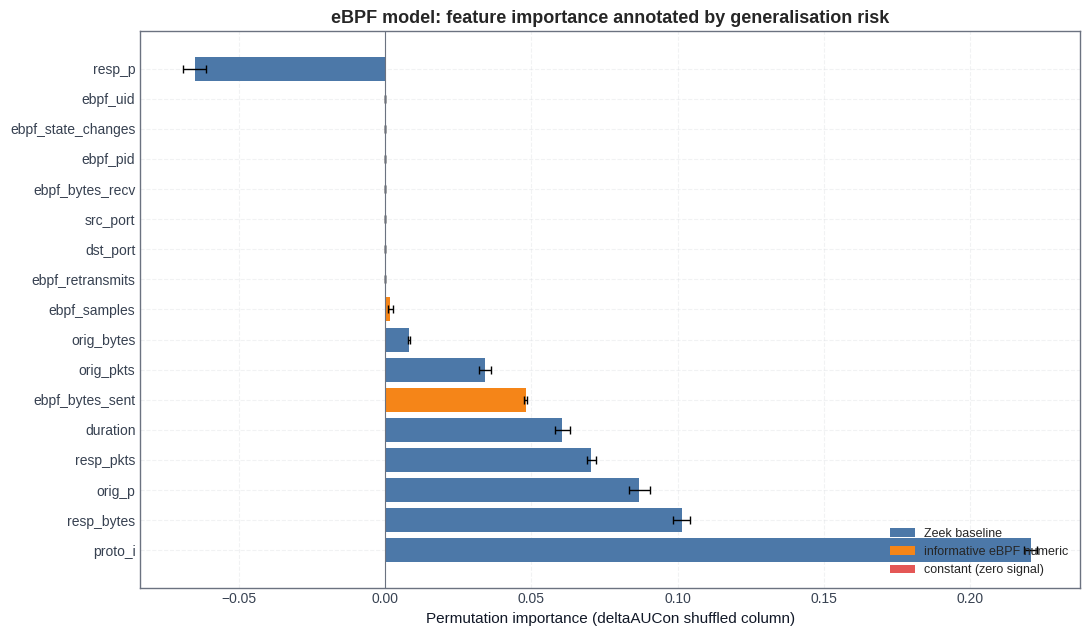

[+] Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/ebpf_feature_risk_annotation.png
[+] Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/ebpf_feature_risk_annotation.csv


In [8]:
CONSTANT_COLS  = {'ebpf_pid', 'ebpf_uid'}   # always 0 or 65534 -> zero signal
NAN_COLS       = {'ebpf_comm'}              # all-NaN -> not in model feature set
NUMERIC_EBPF   = {'ebpf_bytes_sent', 'ebpf_bytes_recv',
                  'ebpf_retransmits', 'ebpf_state_changes', 'ebpf_samples'}

def annotate_risk(feat):
    """Classify a feature name as constant, all-NaN, informative eBPF, or Zeek baseline."""
    f = feat.lower()
    if feat in CONSTANT_COLS:
        return 'constant (zero signal)'
    if feat in NAN_COLS:
        return 'all-NaN (not used)'
    if feat in NUMERIC_EBPF:
        return 'informative eBPF numeric'
    return 'Zeek baseline'

if IMP_EBPF is not None and not IMP_EBPF.empty:
    risk_df = IMP_EBPF[['feature', 'importance_mean', 'importance_std']].copy()
    risk_df['category'] = risk_df['feature'].apply(annotate_risk)
    risk_df = risk_df.sort_values('importance_mean', ascending=False).reset_index(drop=True)

    print('[*] eBPF model feature importance with generalisation risk annotation:')
    print(risk_df.to_string(index=False, float_format='{:.5f}'.format))

    # Colour-coded bar chart
    cat_colors = {
        'Zeek baseline':             BASELINE_COLOR,
        'informative eBPF numeric':  EBPF_COLOR,
        'constant (zero signal)':    '#E45756',
        'all-NaN (not used)':        NEUTRAL_COLOR,
    }
    colors = [cat_colors.get(c, '#888') for c in risk_df['category']]

    fig, ax = plt.subplots(figsize=(11, max(4, len(risk_df) * 0.38)))
    bars = ax.barh(risk_df['feature'], risk_df['importance_mean'], color=colors,
                   xerr=risk_df['importance_std'], capsize=3, error_kw={'linewidth': 1})
    ax.axvline(0, color='#6B7280', linewidth=0.8)
    ax.set_xlabel('Permutation importance (deltaAUCon shuffled column)')
    ax.set_title('eBPF model: feature importance annotated by generalisation risk')

    # Legend
    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=v, label=k) for k, v in cat_colors.items() if k in risk_df['category'].values]
    ax.legend(handles=legend_elems, loc='lower right', fontsize=9)

    plt.tight_layout()
    risk_fig = FI_DIR / 'ebpf_feature_risk_annotation.png'
    fig.savefig(risk_fig, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'[+] Saved: {risk_fig}')

    # Save annotated table
    risk_csv = FI_DIR / 'ebpf_feature_risk_annotation.csv'
    risk_df.to_csv(risk_csv, index=False)
    print(f'[+] Saved: {risk_csv}')
else:
    print('[!] IMP_EBPF not available, run permutation importance cells first.')


## Progressive Ablation

Adds eBPF features one at a time in descending importance order and records AUC after each step. Shows exactly where added eBPF features stop helping.

  Step  1: +ebpf_bytes_sent                 AUC=0.8494
  Step  2: +ebpf_samples                    AUC=0.8005
  Step  3: +ebpf_bytes_recv                 AUC=0.8005
  Step  4: +ebpf_retransmits                AUC=0.8005
  Step  5: +ebpf_state_changes              AUC=0.8005
  Step  6: +ebpf_pid                        AUC=0.8005
  Step  7: +ebpf_uid                        AUC=0.8005

  All eBPF features active: AUC=0.8005
  Zeek-only model (headline): AUCapprox 0.9202


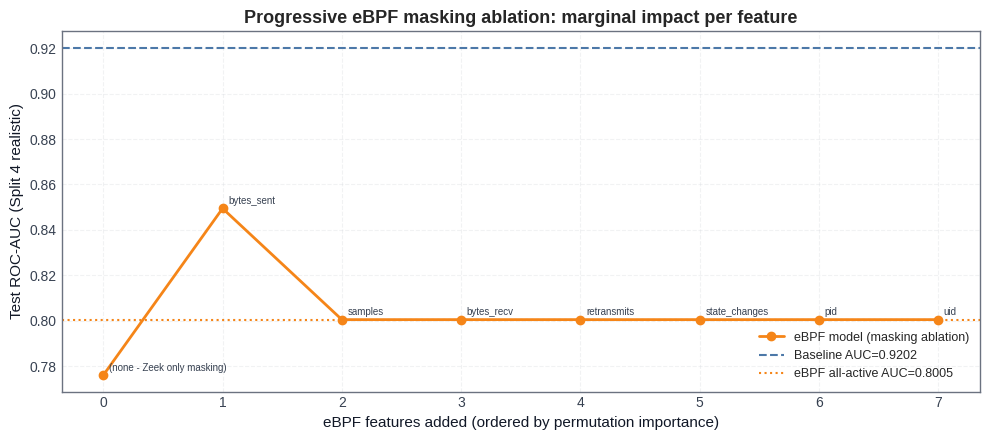

[+] Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/progressive_ebpf_ablation.png
[+] Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed104/progressive_ebpf_ablation.csv


In [9]:
from sklearn.metrics import roc_auc_score

if IMP_EBPF is not None and not IMP_EBPF.empty:
    pack_e = PACKS['ebpf']
    model_e = pack_e['model']
    d_e = DATA['ebpf']

    # Full test set (reuse ablation sample for speed)
    X_full = d_e['Xablate'].copy()
    y_full = d_e['yablate']

    all_feats  = d_e['features']
    ebpf_feats = [f for f in all_feats if any(h in f.lower()
                  for h in ('ebpf','bpf','pid','uid','comm','exe'))]
    # Order by permutation importance descending
    imp_order  = IMP_EBPF.set_index('feature')['importance_mean']
    ebpf_ordered = sorted(ebpf_feats,
                          key=lambda f: -imp_order.get(f, 0.0))

    # Baseline: all eBPF cols zeroed
    abl_rows = []
    X_abl = X_full.copy()
    for col in ebpf_feats:
        if col in X_abl.columns:
            X_abl[col] = 0.0
    score_base = model_e.predict_proba(X_abl)[:, 1]
    abl_rows.append({'step': 0, 'feature_added': '(none - Zeek only masking)',
                     'test_auc': roc_auc_score(y_full, score_base), 'n_ebpf_active': 0})

    X_abl = X_full.copy()
    for col in ebpf_feats:
        if col in X_abl.columns:
            X_abl[col] = 0.0

    for step, feat in enumerate(ebpf_ordered, start=1):
        if feat in X_abl.columns:
            X_abl[feat] = X_full[feat]  # restore this feature
        score = model_e.predict_proba(X_abl)[:, 1]
        auc_val = roc_auc_score(y_full, score)
        abl_rows.append({'step': step, 'feature_added': feat,
                         'test_auc': auc_val, 'n_ebpf_active': step})
        print(f'  Step {step:2d}: +{feat:<30s}  AUC={auc_val:.4f}')

    abl_df = pd.DataFrame(abl_rows)

    # Baseline (all features active) for reference
    score_all = model_e.predict_proba(X_full)[:, 1]
    auc_all   = roc_auc_score(y_full, score_all)
    baseline_auc_zeek = float(pack_e['f1_reference_test_metrics'].get('roc_auc',
                              PACKS['baseline'].get('f1_reference_test_metrics', {}).get('roc_auc', float('nan'))))
    print(f'\n  All eBPF features active: AUC={auc_all:.4f}')
    print(f'  Zeek-only model (headline): AUCapprox 0.9202')

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(abl_df['step'], abl_df['test_auc'], marker='o', color=EBPF_COLOR,
            linewidth=2, markersize=6, label='eBPF model (masking ablation)')
    ax.axhline(0.9202, color=BASELINE_COLOR, linestyle='--', linewidth=1.5,
               label='Baseline AUC=0.9202')
    ax.axhline(auc_all, color=EBPF_COLOR, linestyle=':', linewidth=1.5,
               label=f'eBPF all-active AUC={auc_all:.4f}')
    for i, row in abl_df.iterrows():
        ax.annotate(row['feature_added'].replace('ebpf_', ''),
                    (row['step'], row['test_auc']),
                    xytext=(4, 3), textcoords='offset points', fontsize=7, color='#374151')
    ax.set_xlabel('eBPF features added (ordered by permutation importance)')
    ax.set_ylabel('Test ROC-AUC (Split 4 realistic)')
    ax.set_title('Progressive eBPF masking ablation: marginal impact per feature')
    ax.legend(fontsize=9)
    plt.tight_layout()
    abl_fig = FI_DIR / 'progressive_ebpf_ablation.png'
    fig.savefig(abl_fig, dpi=180, bbox_inches='tight')
    plt.show()

    abl_df.to_csv(FI_DIR / 'progressive_ebpf_ablation.csv', index=False)
    print(f'[+] Saved: {abl_fig}')
    print(f'[+] Saved: {FI_DIR}/progressive_ebpf_ablation.csv')
else:
    print('[!] IMP_EBPF not available, run permutation importance cells first.')


## Summary

**RQ2:** None of the eBPF feature combinations achieves baseline detection accuracy (0.921).

- `ebpf_bytes_sent` is the most important eBPF feature (mean permutation importance: 0.048). Including `ebpf_bytes_sent` alone increases AUC from 0.695 to 0.849
- None of the other eBPF features contributes to performance gain. AUC remains at 0.801 after including each of them separately
- `ebpf_pid` and `ebpf_uid` are constant features (with zero signal)
- AUC without Zeek features but with eBPF features: 0.632

Top five SHAP features are nearly the same in both models (`proto_i`, `resp_bytes`, `resp_p`, `resp_pkts`, `orig_p`). This confirms that the Zeek features drive predictions in both cases.